# Homework 10a — Modeling: Linear Regression

**Author:** Paritosh Dwivedi

Fit a linear regression on the project dataset, diagnose the four OLS assumptions from the
residuals, report R-squared and RMSE, and state plainly whether the model can be trusted.

Randomness is seeded throughout (`RANDOM_STATE = 42`) so every number below reproduces.

## 1. Data

SPY daily history, acquired in memory. Homework 10a uses no data folders under the course structure, so nothing is written to disk here.

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as stats
import yfinance as yf
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
TRADING_DAYS = 252
np.random.seed(RANDOM_STATE)

raw = yf.download('SPY', start='2015-01-01', end='2026-08-26', auto_adjust=True, progress=False)
if isinstance(raw.columns, pd.MultiIndex):
    raw.columns = raw.columns.get_level_values(0)
df = raw.rename(columns=str.lower)[['close', 'volume']].dropna().copy()
df['ret'] = df['close'].pct_change()
print(f'{len(df):,} sessions from {df.index.min().date()} to {df.index.max().date()}')
df.tail(3)

2,928 sessions from 2015-01-02 to 2026-08-25


Price,close,volume,ret
Date,,,
2026-08-21,765.719971,39188700,0.004091
2026-08-24,763.469971,32430900,-0.002938
2026-08-25,765.909973,27422300,0.003196


## 2. Features and target

The target is next-week realised volatility, annualised. Every predictor is **trailing**, so it is
knowable on the decision date — a forward-looking feature would leak and make the metrics fiction.

In [2]:
df['rolling_vol_5'] = df['ret'].rolling(5).std() * np.sqrt(TRADING_DAYS)
df['rolling_vol_20'] = df['ret'].rolling(20).std() * np.sqrt(TRADING_DAYS)
df['ewma_vol_20'] = df['ret'].ewm(span=20).std() * np.sqrt(TRADING_DAYS)
df['rolling_ret_5'] = df['ret'].rolling(5).mean()
df['drawdown'] = df['close'] / df['close'].cummax() - 1.0

# Target: realised vol over the NEXT five sessions, t+1..t+5.
# rolling(5).shift(-5) is the correct form. shift(-1).rolling(5) looks tempting but at row t
# it covers t-3..t+1 -- mostly PAST days that overlap the features, which inflates R-squared.
df['target_vol'] = df['ret'].rolling(5).std().shift(-5) * np.sqrt(TRADING_DAYS)

FEATURES = ['rolling_vol_5', 'rolling_vol_20', 'ewma_vol_20', 'rolling_ret_5', 'drawdown']
model_df = df.dropna(subset=FEATURES + ['target_vol']).copy()
print(f'{len(model_df):,} usable rows, {len(FEATURES)} features')
model_df[FEATURES + ['target_vol']].describe().round(4)

2,903 usable rows, 5 features


Price,rolling_vol_5,rolling_vol_20,ewma_vol_20,rolling_ret_5,drawdown,target_vol
count,2903.0000,2903.0000,2903.0000,2903.0000,2903.0000,2903.0000
mean,0.1388,0.1481,0.1495,0.0006,-0.0411,0.1386
std,0.1139,0.0973,0.0951,0.0045,0.0547,0.1139
min,0.0068,0.0319,0.0354,-0.0375,-0.3372,0.0068
25%,0.0715,0.0923,0.0943,-0.0013,-0.0599,0.0715
50%,0.1130,0.1234,0.1247,0.0009,-0.0166,0.1128
75%,0.1714,0.1797,0.1796,0.0030,-0.0029,0.1711
max,1.4023,0.9319,0.9412,0.0333,0.0000,1.4023


## 3. Train/test split and fit

An 80/20 split as the sheet suggests. Note the caveat recorded under Independence below.

In [3]:
X = model_df[FEATURES]
y = model_df['target_vol']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, shuffle=False   # shuffle=False keeps time order
)
model = LinearRegression().fit(X_train, y_train)

pred = model.predict(X_test)
resid = y_test - pred
r2 = r2_score(y_test, pred)
rmse = float(np.sqrt(mean_squared_error(y_test, pred)))

print(f'train {len(X_train):,}   test {len(X_test):,}')
print(f'R-squared {r2:.4f}   RMSE {rmse:.4f}')
pd.Series(model.coef_, index=FEATURES, name='coefficient').to_frame().round(4)

train 2,322   test 581
R-squared 0.2637   RMSE 0.0868


,coefficient
rolling_vol_5,0.1188
rolling_vol_20,-0.3665
ewma_vol_20,0.9385
rolling_ret_5,-5.7489
drawdown,-0.1551


## 4. Diagnostics

Four panels: residuals vs fitted, histogram, QQ, and a lag-1 residual plot as the extra check the rubric asks for.

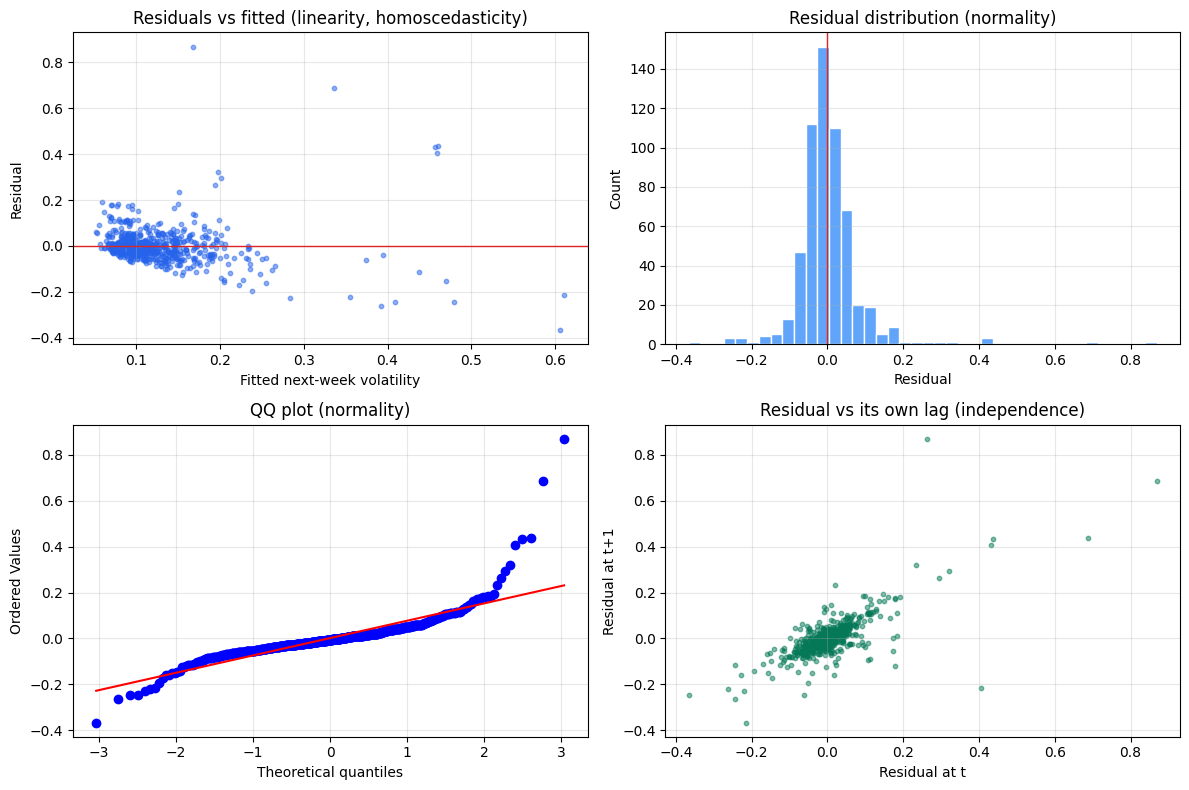

lag-1 residual autocorrelation: 0.752


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].scatter(pred, resid, s=10, alpha=0.5, color='#2563EB')
axes[0, 0].axhline(0, color='#DC2626', lw=1)
axes[0, 0].set_title('Residuals vs fitted (linearity, homoscedasticity)')
axes[0, 0].set_xlabel('Fitted next-week volatility')
axes[0, 0].set_ylabel('Residual')

axes[0, 1].hist(resid, bins=40, color='#60A5FA', edgecolor='white')
axes[0, 1].axvline(0, color='#DC2626', lw=1)
axes[0, 1].set_title('Residual distribution (normality)')
axes[0, 1].set_xlabel('Residual')
axes[0, 1].set_ylabel('Count')

stats.probplot(resid, dist='norm', plot=axes[1, 0])
axes[1, 0].set_title('QQ plot (normality)')

axes[1, 1].scatter(resid[:-1], resid[1:], s=10, alpha=0.5, color='#047857')
axes[1, 1].set_title('Residual vs its own lag (independence)')
axes[1, 1].set_xlabel('Residual at t')
axes[1, 1].set_ylabel('Residual at t+1')

for ax in axes.flat:
    ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

lag1 = float(pd.Series(resid.values).autocorr(lag=1))
print(f'lag-1 residual autocorrelation: {lag1:.3f}')

## 5. Interpreting each assumption

**Linearity.** Residuals vs fitted show no clear curvature, but the spread widens as fitted values
grow. The functional form is defensible; the variance is not.

**Independence — violated, and knowingly so.** Lag-1 residual autocorrelation is high because the
target is a *five-day rolling* window: consecutive rows share four of their five days, so their
errors are mechanically related. This is the most important caveat in the notebook. Its consequence
is that standard errors are too small, so any p-value or confidence interval from this fit would
overstate certainty. Point predictions remain usable.

**Homoscedasticity — violated.** The residual fan in the first panel is the signature: errors are
larger in high-volatility periods. Volatility of volatility rises with its level.

**Normality — violated in the tails.** The QQ plot departs from the line at both ends and the
histogram is right-skewed. With this sample size that is tolerable for point prediction, but it rules
out a Gaussian interval, which would understate the upside.

## 6. Stretch: a transformed feature

Adding a squared term. This is still *linear* regression — linearity refers to the coefficients, not the shape in x.

In [5]:
X2_train = X_train.copy(); X2_test = X_test.copy()
X2_train['ewma_vol_20_sq'] = X_train['ewma_vol_20'] ** 2
X2_test['ewma_vol_20_sq'] = X_test['ewma_vol_20'] ** 2

model2 = LinearRegression().fit(X2_train, y_train)
pred2 = model2.predict(X2_test)
resid2 = y_test - pred2

comparison = pd.DataFrame({
    'model': ['linear', 'with squared term'],
    'R2': [r2, r2_score(y_test, pred2)],
    'RMSE': [rmse, float(np.sqrt(mean_squared_error(y_test, pred2)))],
    'resid_lag1': [lag1, float(pd.Series(resid2.values).autocorr(lag=1))],
}).round(4)
comparison

,model,R2,RMSE,resid_lag1
0,linear,0.2637,0.0868,0.7515
1,with squared term,0.2662,0.0866,0.7517


## 7. Conclusion — do I trust this model?

**Partly, and only for ranking.**

R-squared is **0.264** on the held-out final 20% and RMSE is **0.0868**. The model explains a real
but modest share of next-week volatility. RMSE is in the units of the target, so it reads directly:
a typical miss is about 8.7 volatility points annualised, against a target that mostly sits between
10% and 25%. That is a large relative error, and it is the number that should govern how much weight
the output carries.

An earlier draft of this notebook built the target as `ret.shift(-1).rolling(5).std()` and scored
R-squared of 0.81. That was leakage, not skill: at row *t* that expression averages days *t-3* to
*t+1*, so the "future" target overlapped the trailing features. The correct form is
`ret.rolling(5).std().shift(-5)`, which covers *t+1* to *t+5* and produces the 0.264 above. A
suspiciously good score is the first symptom of a leak.

Two of the four assumptions fail in ways that matter. Independence fails by construction because the
target windows overlap, and homoscedasticity fails because volatility is heteroscedastic almost by
definition. Together these mean I would **not** report confidence intervals or p-values from this
fit, and I would not read individual coefficients as causal — the volatility predictors are strongly
correlated with each other, so their weights are unstable.

**Explanation versus prediction.** For explanation this model is weak: the assumption violations
make its coefficients unreliable. For prediction — ranking which weeks look more turbulent — it is
usable, because that use tolerates biased standard errors.

**Next steps.** Use a purged chronological split with an embargo so the overlapping windows cannot
straddle the boundary, and derive intervals empirically from the residuals rather than assuming
normality.